In [432]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import joblib       # to save the trained model to disk.

In [433]:
df = pd.read_csv("../data/AAPL_features.csv", index_col=0, parse_dates=True)
print(df.shape)
df.head()



(2467, 27)


,Close,High,Low,Open,Volume,return,lag1,lag2,lag3,sma5,...,volatility_10,volatility_20,vol_ratio,rsi,rsi_slope,volume_ma20,volume_ratio,vol_confirmed_move,day_of_week,target
Price,,,,,,,,,,,,,,,,,,,,,
2015-03-16,27.758121,27.758121,27.296043,27.520417,143497200.0,0.011004,-0.006911,0.018079,-0.018232,27.535528,...,0.012886,0.013712,0.939806,32.710634,-3.065723,234379600.0,0.612243,-0.004231,0,1
2015-03-17,28.222429,28.284632,27.913636,27.969174,204092400.0,0.016727,0.011004,-0.006911,0.018079,27.647937,...,0.014304,0.014193,1.007823,45.533450,6.516412,231953740.0,0.879884,0.009682,1,1
2015-03-18,28.540108,28.693394,28.073585,28.213541,261083600.0,0.011256,0.016727,0.011004,-0.006911,27.924741,...,0.014748,0.014339,1.028486,44.971637,18.092100,236029580.0,1.106148,0.018502,2,0
2015-03-19,28.324615,28.713385,28.302400,28.602308,183238000.0,-0.007551,0.011256,0.016727,0.011004,28.060254,...,0.013868,0.014433,0.960886,47.391182,14.680548,237719000.0,0.770818,0.008677,3,0
2015-03-20,27.969170,28.524553,27.804776,28.491231,274780400.0,-0.012549,-0.007551,0.011256,0.016727,28.162889,...,0.014503,0.014538,0.997585,41.765681,-3.767770,241668340.0,1.137014,-0.008585,4,1


In [434]:
features = [
    "lag1", "lag2", "lag3",
    "momentum_5", "momentum_20",
    "price_to_sma20", "price_to_sma50", "sma_cross",
    "volatility_10", "volatility_20", "vol_ratio",
    "rsi", "rsi_slope",
    "volume_ratio", "vol_confirmed_move", "day_of_week"
]

X = df[features]
y = df["target"]

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (2467, 16)
Target distribution:
target
1    1307
0    1160
Name: count, dtype: int64


#### 80/20 splitting

In [435]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]        # iloc means "select by position number"
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Training set:  {X_train.shape[0]} rows  ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Test set:      {X_test.shape[0]} rows  ({X_test.index[0].date()} to {X_test.index[-1].date()})")

Training set:  1973 rows  (2015-03-16 to 2023-01-12)
Test set:      494 rows  (2023-01-13 to 2024-12-31)


fit_transform on training data — it learns the scaling from training data <br>
transform only on test data — it applies the same scaling without re-learning <br><br>

Never fit the scaler on test data. That would leak information from the future.

In [436]:
# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)

#### Training tthe random forest

In [437]:
model = RandomForestClassifier(n_estimators=300, 
                               max_depth=4, 
                               min_samples_leaf=75, 
                               max_features=0.3,
                               class_weight= 'balanced',
                               random_state=42, 
                               n_jobs=-1)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",75
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [438]:
model.score(X_test, y_test)

0.48582995951417

In [439]:
print("Train:", model.score(X_train, y_train))
print("Test: ", model.score(X_test, y_test))

Train: 0.6315255955397872
Test:  0.48582995951417


In [440]:
preds       = model.predict(X_test)      # predict gives you hard labels (0 or 1).
preds_proba = model.predict_proba(X_test)[:, 1] # predict_proba gives you the model's confidence — a value between 0 and 1 for each prediction.
print(f"Predictions sample: {preds[:10]}")      
print(f"Probabilities sample: {preds_proba[:10].round(3)}")

Predictions sample: [1 1 1 0 1 0 0 0 0 0]
Probabilities sample: [0.521 0.523 0.509 0.494 0.534 0.475 0.459 0.45  0.457 0.459]


In [441]:
print("Classification Report:")
print(classification_report(y_test, preds, target_names=["Down (0)", "Up (1)"]))

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.43      0.48      0.45       218
      Up (1)       0.54      0.49      0.52       276

    accuracy                           0.49       494
   macro avg       0.49      0.49      0.48       494
weighted avg       0.49      0.49      0.49       494



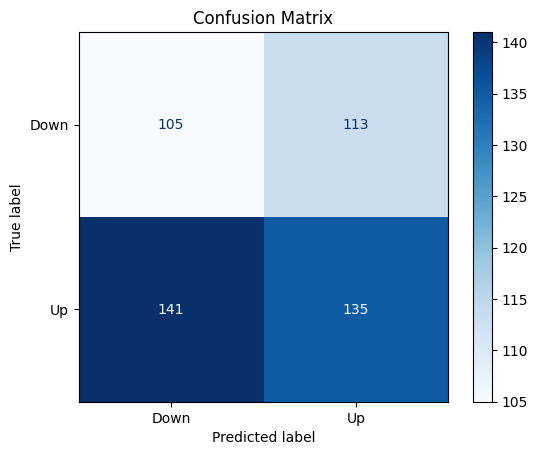

In [442]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down", "Up"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()